In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk

In [4]:
file='~/Desktop/Project/placement_predictor/Dataset/Placement_Prediction_data.csv'
data=pd.read_csv(file)
data.head()

,Unnamed: 0,StudentId,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,Internship,Hackathon,12th Percentage,10th Percentage,backlogs,PlacementStatus
0,0,1,7.5,1,1,1,6,4.4,No,No,61,79,2,NotPlaced
1,1,2,8.9,0,3,2,9,4.0,Yes,Yes,78,82,0,Placed
2,2,3,7.3,1,2,2,8,4.8,Yes,No,79,80,2,NotPlaced
3,3,4,7.5,1,1,2,8,4.4,Yes,Yes,81,80,0,Placed
4,4,5,8.3,1,2,2,8,4.5,Yes,Yes,74,88,0,Placed


In [5]:
data.isnull().sum()

Unnamed: 0                    0
StudentId                     0
CGPA                          0
Major Projects                0
Workshops/Certificatios       0
Mini Projects                 0
Skills                        0
Communication Skill Rating    0
Internship                    0
Hackathon                     0
12th Percentage               0
10th Percentage               0
backlogs                      0
PlacementStatus               0
dtype: int64

In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  10000 non-null  int64  
 1   StudentId                   10000 non-null  int64  
 2   CGPA                        10000 non-null  float64
 3   Major Projects              10000 non-null  int64  
 4   Workshops/Certificatios     10000 non-null  int64  
 5   Mini Projects               10000 non-null  int64  
 6   Skills                      10000 non-null  int64  
 7   Communication Skill Rating  10000 non-null  float64
 8   Internship                  10000 non-null  str    
 9   Hackathon                   10000 non-null  str    
 10  12th Percentage             10000 non-null  int64  
 11  10th Percentage             10000 non-null  int64  
 12  backlogs                    10000 non-null  int64  
 13  PlacementStatus             10000 non-null 

In [7]:
for col in data.columns:
    print(col,data[col].nunique())

Unnamed: 0 10000
StudentId 10000
CGPA 27
Major Projects 3
Workshops/Certificatios 4
Mini Projects 4
Skills 4
Communication Skill Rating 19
Internship 2
Hackathon 2
12th Percentage 36
10th Percentage 32
backlogs 8
PlacementStatus 2


<Axes: xlabel='PlacementStatus', ylabel='count'>

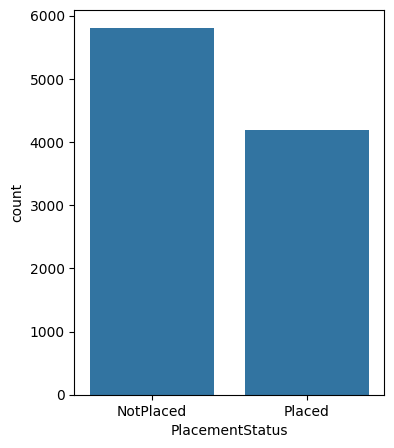

In [8]:
plt.figure(figsize=(4,5))
sns.countplot(x='PlacementStatus', data=data)

In [9]:
data['PlacementStatus']=data.PlacementStatus.apply(lambda x:1 if x=='Placed' else 0)
data['Internship']=data.Internship.apply(lambda x:1 if x=='Yes' else 0)
data['Hackathon']=data.Hackathon.apply(lambda x:1 if x=='Yes' else 0)

<Axes: >

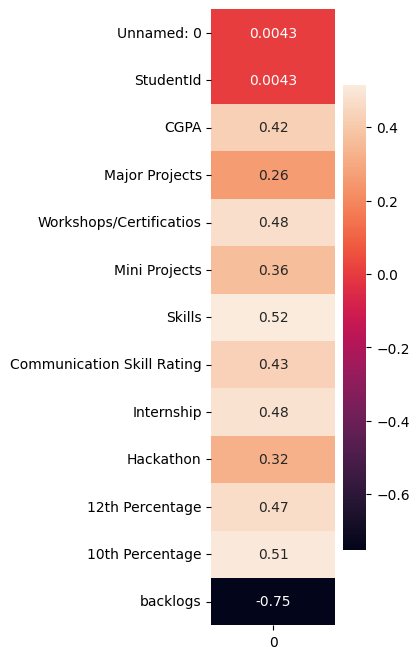

In [10]:
plt.figure(figsize=(2,8))
sns.heatmap(data.drop('PlacementStatus', axis=1).corrwith(data['PlacementStatus']).to_frame(), annot=True)

In [11]:
data.drop(['StudentId', 'Unnamed: 0'], axis=1, inplace=True)

In [12]:
data.head()

,CGPA,Major Projects,Workshops/Certificatios,Mini Projects,Skills,Communication Skill Rating,Internship,Hackathon,12th Percentage,10th Percentage,backlogs,PlacementStatus
0,7.5,1,1,1,6,4.4,0,0,61,79,2,0
1,8.9,0,3,2,9,4.0,1,1,78,82,0,1
2,7.3,1,2,2,8,4.8,1,0,79,80,2,0
3,7.5,1,1,2,8,4.4,1,1,81,80,0,1
4,8.3,1,2,2,8,4.5,1,1,74,88,0,1


In [16]:
X=data.drop('PlacementStatus', axis=1)
y=data['PlacementStatus']

In [17]:
X_train, X_test, y_train, y_test = sk.model_selection.train_test_split(X, y, test_size=0.2, random_state=77)

In [52]:
pipe = sk.pipeline.Pipeline([('standard_scaler',sk.preprocessing.StandardScaler())
                            ,('KNN', sk.linear_model.LogisticRegression())])

In [53]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standard_scaler', ...), ('KNN', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may

In [54]:
y_pred= pipe.predict(X_test)

In [55]:
cm=sk.metrics.confusion_matrix(y_test,y_pred)

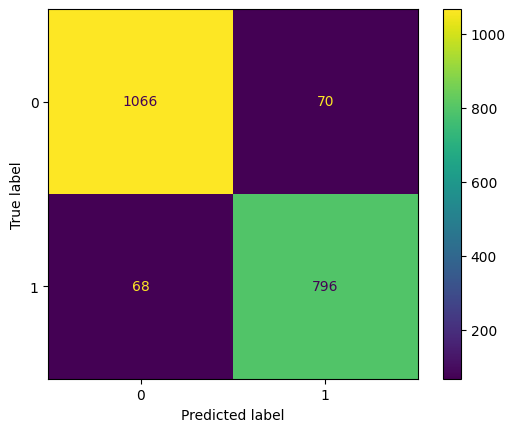

In [56]:
dis=sk.metrics.ConfusionMatrixDisplay(cm)
dis.plot()

In [57]:
display(sk.metrics.accuracy_score(y_test, y_pred))
display(sk.metrics.precision_score(y_test, y_pred))

0.931

0.9191685912240185